---
date: "2026-05-09"
date-modified: last-modified
format:
  html:
    toc: true
---


# 1. Functions of Random Variables

Because a [random variable](random-variables.ipynb) $X$ maps sample outcomes to real numbers, we can feed those resulting real numbers into another mathematical function $g$.

**Definition:** For an experiment with sample space $S$, a random variable $X$, and a function $g: \mathbb{R} \to \mathbb{R}$, the composition $g(X)$ defines a new random variable. This new r.v. simply maps an outcome $s$ to the value $g(X(s))$.
This logic extends to functions of multiple variables: $g(X, Y)$ maps $s$ to $g(X(s), Y(s))$.

**Theorem (PMF of $g(X)$):** Let $X$ be a discrete r.v. and let $Y = g(X)$. The probability that $Y$ equals a specific value $y$ is found by summing the probabilities of all underlying $x$ values that map to $y$:

$$P(g(X) = y) = \sum_{x : g(x)=y} P(X = x)$$

*Note: If $g$ is a one-to-one function, the sum collapses, and $P(Y=g(x))$ simply equals $P(X=x)$ for each mapped value*.

## 1.1 Measurability Considerations

::: {.callout-warning title="Theoretical Depth: Borel Measurability"}
In rigorous measure-theoretic probability, we cannot use just *any* arbitrary function $g$. For $g(X)$ to technically qualify as a random variable, $g$ must be a **Borel-measurable function**.

A random variable must guarantee that the set of pre-images $\{s \in S : g(X(s)) \le y\}$ forms a valid mathematical event in our sample space. If $g$ is a pathologically unmeasurable function, it could fracture the real number line so severely that the pre-image is no longer a valid event, making it impossible to assign a probability to it! For standard functions (polynomials, absolute values, limits), measurability is guaranteed, but it remains the critical theoretical foundation for stochastic analysis.
:::

## 1.2 Example: The Random Walk

Imagine a particle starts at $0$ and takes $n$ independent steps. Each step moves $+1$ (right) or $-1$ (left) with equal probability. Let $Y$ be the final position.

We can define $X \sim \text{Bin}(n, 1/2)$ as the number of rightward steps. The number of leftward steps is $n - X$.
The final position $Y$ is a function of $X$:

$$Y = 1(X) - 1(n - X) = 2X - n$$

To find the PMF of $Y$, we solve for $X$ and substitute into the Binomial PMF:

$$P(Y = k) = P(2X - n = k) = P\left(X = \frac{n+k}{2}\right) = \binom{n}{\frac{n+k}{2}} \left(\frac{1}{2}\right)^n$$

If we wanted the *distance* from the origin, $D = |Y|$. Because the absolute value function is not one-to-one, we sum the probabilities:

$$P(D = k) = P(Y = k) + P(Y = -k)$$

## 1.4 Static Visualization

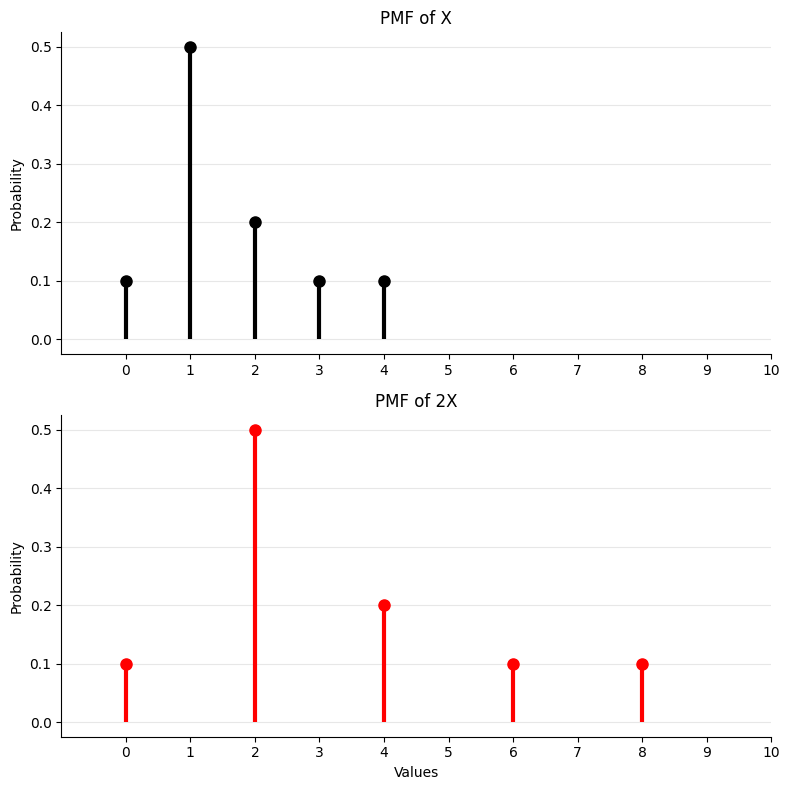

In [1]:
#| label: fig-sympathetic-magic
#| fig-cap: "Multiplying a random variable stretches its support horizontally. It does not stretch the probabilities vertically."

import matplotlib.pyplot as plt
import numpy as np

x_support = np.array([0, 1, 2, 3, 4])
pmf_x = np.array([0.1, 0.5, 0.2, 0.1, 0.1])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharey=True)

# Plot PMF of X
ax1.vlines(x_support, 0, pmf_x, colors='black', lw=3)
ax1.plot(x_support, pmf_x, 'ko', markersize=8)
ax1.set_title('PMF of X')
ax1.set_ylabel('Probability')
ax1.set_xticks(np.arange(0, 11))
ax1.set_xlim(-1, 10)
ax1.grid(axis='y', alpha=0.3)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Plot PMF of 2X
x_support_2x = x_support * 2
ax2.vlines(x_support_2x, 0, pmf_x, colors='red', lw=3)
ax2.plot(x_support_2x, pmf_x, 'ro', markersize=8)
ax2.set_title('PMF of 2X')
ax2.set_xlabel('Values')
ax2.set_ylabel('Probability')
ax2.set_xticks(np.arange(0, 11))
ax2.set_xlim(-1, 10)
ax2.grid(axis='y', alpha=0.3)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()